# Stationary Heston Simulation

This notebook aims to reproduce and analyse some of the main ideas of the article. The first objective is to compare the three initial-variance choices:

- `GAMMA`: draw the initial variance from the invariant Gamma law of the CIR process,
- `MEAN`: start deterministically from the long-run level `theta`,
- `LAST_VALUE`: start from a fixed observed variance level, here `0.0045` as in the article.

**Methodological note.** In this first part, the three strategies are compared under the **same Heston parameters**. This is deliberate: it isolates the effect of the initialisation rule itself. If we used the two different calibrated parameter sets of Table 2 at the same time, we would mix two effects together: a change of initialisation and a change of model parameters.

The analysis is split in three blocks:

1. the standalone CIR variance process,
2. the full Heston asset/variance dynamics under the same three initialisations,
3. the pricing of European, Bermudan, and Barrier options.

In [ ]:
# Useful imports

from __future__ import annotations

import sys

import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, "../")

plt.style.use("seaborn-v0_8-whitegrid")

from stationary_heston_model import (
    BarrierDirection,
    BarrierOption,
    BermudanOption,
    CIRStationarySimulator,
    EuropeanOption,
    HestonPathSimulator,
    InitialVarianceStrategy,
    OptionType,
)


## Model setup  

The volatility process is the CIR diffusion

$$
dv_t = \, \kappa(\theta - v_t)\,dt + \xi \sqrt{v_t}\,dW_t,
$$

with invariant law

$$
\nu = \Gamma(\alpha, \beta), \qquad \alpha = \frac{2\kappa\theta}{\xi^2}, \qquad \beta = \frac{2\kappa}{\xi^2},
$$

using the paper's shape-rate parameterisation. In the repository implementation, the stationary sampler therefore uses the equivalent shape-scale form with $\text{scale} = \frac{1}{\beta}$.

We use the penalised calibration reported in Table 2 of the paper. Reproducing the values directly in Markdown, modulo $S_0$, gives:

| Model | $r$ | $q$ | $\rho$ | $v_0$ | $\theta$ | $\kappa$ | $\xi$ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Standard Heston | -0.0032 | 0.00225 | -0.83 | 0.0045 | 0.17023 | 2.19 | 1.04 |
| Stationary Heston | -0.0032 | 0.00225 | -0.99 | n/a | 0.02691 | 19.28 | 1.15 |

For the stationary model, $v_0$ is not a deterministic calibrated parameter: the paper uses $v_0^\nu \sim \Gamma(\alpha, \beta)$. In the simulations below, we keep $S_0 = 100$ for convenience and use last variance $v_0 = 0.0045$ when comparing against the deterministic `LAST_VALUE` strategy.

A useful benchmark is the exact conditional mean of the CIR process:

$$
\mathbb{E}[v_t \mid v_0] = \theta + (v_0 - \theta)e^{-\kappa t}.
$$

This formula is enough to anticipate most of the comparisons below: `MEAN` starts directly at the long-run level, `LAST_VALUE` mean-reverts exponentially towards it, and `GAMMA` is stationary from time zero because its full distribution is already invariant.


In [2]:
s0 = 100
r = -0.0032
q = 0.00225
kappa = 19.28
theta = 0.02691
xi = 1.15
rho = -0.99
last_variance = 0.0045

short_maturity = 7 / 252
half_year = 0.5
n_paths = 30000

strategy_order = [
    InitialVarianceStrategy.GAMMA,
    InitialVarianceStrategy.MEAN,
    InitialVarianceStrategy.LAST_VALUE,
]
strategy_labels = {
    InitialVarianceStrategy.GAMMA: "GAMMA",
    InitialVarianceStrategy.MEAN: "MEAN",
    InitialVarianceStrategy.LAST_VALUE: "LAST_VALUE",
}
strategy_colors = {
    InitialVarianceStrategy.GAMMA: "#1f77b4",
    InitialVarianceStrategy.MEAN: "#2ca02c",
    InitialVarianceStrategy.LAST_VALUE: "#d62728",
}

alpha = 2.0 * kappa * theta / xi**2
beta = 2.0 * kappa / xi**2
scale = 1.0 / beta 
feller_gap = 2.0 * kappa * theta - xi**2

parameter_table = {
    "s0" : s0,
    "r" : r,
    "q" : q,
    "theta" : theta,
    "kappa" : kappa,
    "xi" : xi,
    "rho": rho,
    "last_variance" : last_variance,
    "stationary alpha" : alpha,
    "stationary beta" : beta,
    "stationary scale" : scale,
    "feller_gap" : feller_gap,
}

parameter_table


{'s0': 100,
 'r': -0.0032,
 'q': 0.00225,
 'theta': 0.02691,
 'kappa': 19.28,
 'xi': 1.15,
 'rho': -0.99,
 'last_variance': 0.0045,
 'stationary alpha': 0.7846121739130436,
 'stationary beta': 29.156899810964088,
 'stationary scale': 0.03429719917012448,
 'feller_gap': -0.28485039999999984}

The last row is negative, so the calibrated parameters do not satisfy the Feller condition. That is consistent with the discussion in the paper: even after penalisation, the calibration does not force the constraint. The repository therefore uses the boosted Milstein step for the variance and floors the numerical state at `1e-6` for robustness.

The helper functions below keep the notebook compact and make the comparisons reproducible.


In [ ]:
def time_steps_for(maturity: float) -> int:
    return max(20, int(np.ceil(252 * maturity)))


def last_variance_for(strategy: InitialVarianceStrategy) -> float | None:
    if strategy == InitialVarianceStrategy.LAST_VALUE:
        return last_variance
    return None


def create_heston_simulator(seed: int | None = None) -> HestonPathSimulator:
    rng = np.random.default_rng(seed) if seed is not None else None
    return HestonPathSimulator(
        s0=s0,
        r=r,
        q=q,
        kappa=kappa,
        theta=theta,
        xi=xi,
        rho=rho,
        rng=rng,
    )


def safe_skewness(sample: np.ndarray) -> float:
    if np.std(sample, ddof=1) < 1e-14:
        return np.nan
    return float(scipy.stats.skew(sample, bias=False))


def safe_kurtosis(sample: np.ndarray) -> float:
    if np.std(sample, ddof=1) < 1e-14:
        return np.nan
    return float(scipy.stats.kurtosis(sample, fisher=False, bias=False))


def simulate_cir_bundle(parameters: dict[str, float], maturity: float, n_steps: int, n_paths: int, seed: int | None = None) -> dict[InitialVarianceStrategy, dict[str, np.ndarray]]:
    rng = np.random.default_rng(seed) if seed is not None else None
    results = {}
    for strategy in strategy_order:
        simulator = CIRStationarySimulator(
            theta=parameters["theta"],
            kappa=parameters["kappa"],
            xi=parameters["xi"],
            rng=rng,
        )
        last_variance_value = parameters["last_variance"] if strategy == InitialVarianceStrategy.LAST_VALUE else None
        times, variance = simulator.simulate(
            maturity=maturity,
            n_steps=n_steps,
            n_paths=n_paths,
            strategy=strategy,
            last_variance=last_variance_value,
        )
        results[strategy] = {"times": times, "variance": variance}
    return results


def simulate_heston_bundle(parameters: dict[str, float], maturity: float, n_steps: int, n_paths: int, seed: int | None = None) -> dict[InitialVarianceStrategy, dict[str, np.ndarray]]:
    rng = np.random.default_rng(seed) if seed is not None else None
    times = np.linspace(0.0, maturity, n_steps + 1)
    results = {}
    for strategy in strategy_order:
        simulator = HestonPathSimulator(
            s0=parameters["s0"],
            r=parameters["r"],
            q=parameters["q"],
            kappa=parameters["kappa"],
            theta=parameters["theta"],
            xi=parameters["xi"],
            rho=parameters["rho"],
            rng=rng,
        )
        last_variance_value = parameters["last_variance"] if strategy == InitialVarianceStrategy.LAST_VALUE else None
        spot, variance = simulator.simulate(
            maturity=maturity,
            n_steps=n_steps,
            n_paths=n_paths,
            strategy=strategy,
            last_variance=last_variance_value,
        )
        results[strategy] = {"times": times, "spot": spot, "variance": variance}
    return results


def summarise_cir_bundle(bundle: dict[InitialVarianceStrategy, dict[str, np.ndarray]]) -> pd.DataFrame:
    rows = []

    for strategy in strategy_order:
        times = bundle[strategy]["times"]
        variance = bundle[strategy]["variance"]

        for time_index, time in enumerate(times):
            sample = variance[:, time_index]
            rows.append(
                {
                    "strategy": strategy_labels[strategy],
                    "time": float(time) * 252,
                    "mean": float(np.mean(sample)),
                    "std": float(np.std(sample, ddof=1)),
                    "variance": float(np.var(sample, ddof=1)),
                    "q05": float(np.quantile(sample, 0.05)),
                    "median": float(np.quantile(sample, 0.50)),
                    "q95": float(np.quantile(sample, 0.95)),
                    "skewness": safe_skewness(sample),
                    "kurtosis": safe_kurtosis(sample),
                }
            )

    return pd.DataFrame(rows).set_index(["strategy", "time"]).sort_index()


def summarise_heston_bundle(bundle: dict[InitialVarianceStrategy, dict[str, np.ndarray]]) -> pd.DataFrame:
    rows = []

    for strategy in strategy_order:
        times = bundle[strategy]["times"]
        spot_paths = bundle[strategy]["spot"]
        variance_paths = bundle[strategy]["variance"]
        log_return_increments = np.diff(np.log(spot_paths), axis=1)

        for time_index, time in enumerate(times[1:], start=1):
            spot = spot_paths[:, time_index]
            variance = variance_paths[:, time_index]
            log_returns = np.log(spot / s0)
            log_return_step = log_return_increments[:, time_index - 1]
            target_mean = s0 * np.exp((r - q) * time)

            rows.append(
                {
                    "strategy": strategy_labels[strategy],
                    "time": float(time) * 252,
                    "E[S_t]": float(np.mean(spot)),
                    "risk-neutral target": float(target_mean),
                    "Std(S_t)": float(np.std(spot, ddof=1)),
                    "Q05(S_t)": float(np.quantile(spot, 0.05)),
                    "Q95(S_t)": float(np.quantile(spot, 0.95)),
                    "P(S_t < 95)": float(np.mean(spot < 95.0)),
                    "P(S_t > 105)": float(np.mean(spot > 105.0)),
                    "E[log-return step]": float(np.mean(log_return_step)),
                    "Std(log-return)": float(np.std(log_returns, ddof=1)),
                    "Skew(log-return)": safe_skewness(log_returns),
                    "Corr(log-return, v_t)": float(np.corrcoef(log_returns, variance)[0, 1]),
                    "E[v_t]": float(np.mean(variance)),
                }
            )

    return pd.DataFrame(rows).set_index(["strategy", "time"]).sort_index()


## 1. CIR simulation under the three initialisations

The CIR block is the cleanest place to understand what changes when we modify the initial variance law.
We compare:

- the distribution at time zero,
- the distribution after **7 trading days**, where the initial condition should still matter,
- the distribution after **6 months**, where the process should have mostly forgotten how it started.


In [81]:
cir_short = simulate_cir_bundle(parameters=parameter_table, maturity=short_maturity, n_steps=int(short_maturity * 252), n_paths=n_paths)
cir_half = simulate_cir_bundle(parameters=parameter_table, maturity=half_year, n_steps=int(half_year * 252), n_paths=n_paths)

summary_short = summarise_cir_bundle(cir_short)
summary_half = summarise_cir_bundle(cir_half)

print("Initial v0")
display(summary_short.loc[summary_short.index.get_level_values("time") == 0.0])

print("terminal v_7d")
display(summary_short.loc[summary_short.index.get_level_values("time") == 7.0])

print("terminal v_6m")
display(summary_half.loc[summary_half.index.get_level_values("time") == 126.0])



/home/c17180/Documents/cours/el_karoui/StationaryHestonModel/notebooks/../stationary_heston_model/diffusions/cir.py:43: UserWarning: The Feller condition is not satisfied.
  warn("The Feller condition is not satisfied.")
/tmp/ipykernel_13465/2548942595.py:60: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skewness": float(scipy.stats.skew(sample, bias=False)),
/tmp/ipykernel_13465/2548942595.py:61: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "kurtosis": float(scipy.stats.kurtosis(sample, fisher=False, bias=False)


Initial v0


,,mean,std,variance,q05,median,q95,skewness,kurtosis
strategy,time,,,,,,,,
GAMMA,0.0,0.02665,3.023693e-02,9.142719e-04,0.00070,0.01640,0.087346,2.294895,10.900810
LAST_VALUE,0.0,0.00450,0.000000e+00,0.000000e+00,0.00450,0.00450,0.004500,NaN,NaN
MEAN,0.0,0.02691,1.040851e-17,1.083372e-34,0.02691,0.02691,0.026910,1.000050,0.999867


terminal v_7d


,,mean,std,variance,q05,median,q95,skewness,kurtosis
strategy,time,,,,,,,,
GAMMA,7.0,0.026214,0.029677,0.000881,0.001055,0.016185,0.085637,2.347414,11.353151
LAST_VALUE,7.0,0.013414,0.014553,0.000212,0.000830,0.008595,0.042670,2.174668,9.684339
MEAN,7.0,0.026524,0.023845,0.000569,0.001438,0.020100,0.074086,1.543434,6.303852


terminal v_6m


,,mean,std,variance,q05,median,q95,skewness,kurtosis
strategy,time,,,,,,,,
GAMMA,126.0,0.026052,0.029304,0.000859,0.001023,0.016105,0.085592,2.261288,10.615583
LAST_VALUE,126.0,0.025842,0.029261,0.000856,0.001023,0.016006,0.084309,2.368279,11.658192
MEAN,126.0,0.025991,0.029084,0.000846,0.001041,0.016274,0.084271,2.255345,10.305925


For the `GAMMA` strategy, the theoretical benchmark is the invariant Gamma law of the CIR process. This means that the expected mean, variance, skewness, and kurtosis are the Gamma moments

$$
\mathbb{E}[v]=\frac{\alpha}{\beta}=\theta, \qquad \mathrm{Var}(v)=\frac{\alpha}{\beta^2}, \qquad \mathrm{Skew}(v)=\frac{2}{\sqrt{\alpha}}, \qquad \mathrm{Kurt}(v)=3+\frac{6}{\alpha}.
$$

In the Monte Carlo output, `GAMMA` should stay close to these values at every date, while `MEAN` and `LAST_VALUE` should converge to them as the CIR process forgets its deterministic start.

In [41]:
cir_theoretical = {
    "mean": alpha / beta,
    "std": float(np.sqrt(alpha / beta **2)),
    "variance": alpha / beta**2,
    "skewness": float(2.0 / np.sqrt(alpha)),
    "kurtosis": 3.0 + 6.0 / alpha
}

print("Theorical moments of the Gamma law of the CIR process")
display(cir_theoretical)


Theorical moments of the Gamma law of the CIR process


{'mean': 0.02691,
 'std': 0.0303798885723442,
 'variance': 0.0009229376296680497,
 'skewness': 2.2578884111738535,
 'kurtosis': 10.647090115969782}

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, constrained_layout=True)
plot_specs = [
    ("mean", "Mean"),
    ("variance", "Variance"),
    ("skewness", "Skewness"),
    ("kurtosis", "Kurtosis"),
]

for ax, (column, title) in zip(axes.flat, plot_specs):
    for strategy in strategy_order:
        label = strategy_labels[strategy]
        data = summary_half.loc[label]
        ax.plot(data.index, data[column], color=strategy_colors[strategy], linewidth=2, label=label)
    ax.axhline(cir_theoretical[column], color="black", linestyle="--", linewidth=1.5, label="theoretical Gamma")
    ax.set_title(f"CIR {title.lower()} convergence")
    ax.set_xlabel("time (trading days)")
    ax.set_ylabel(title.lower())

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncols=4, frameon=True)
plt.show()


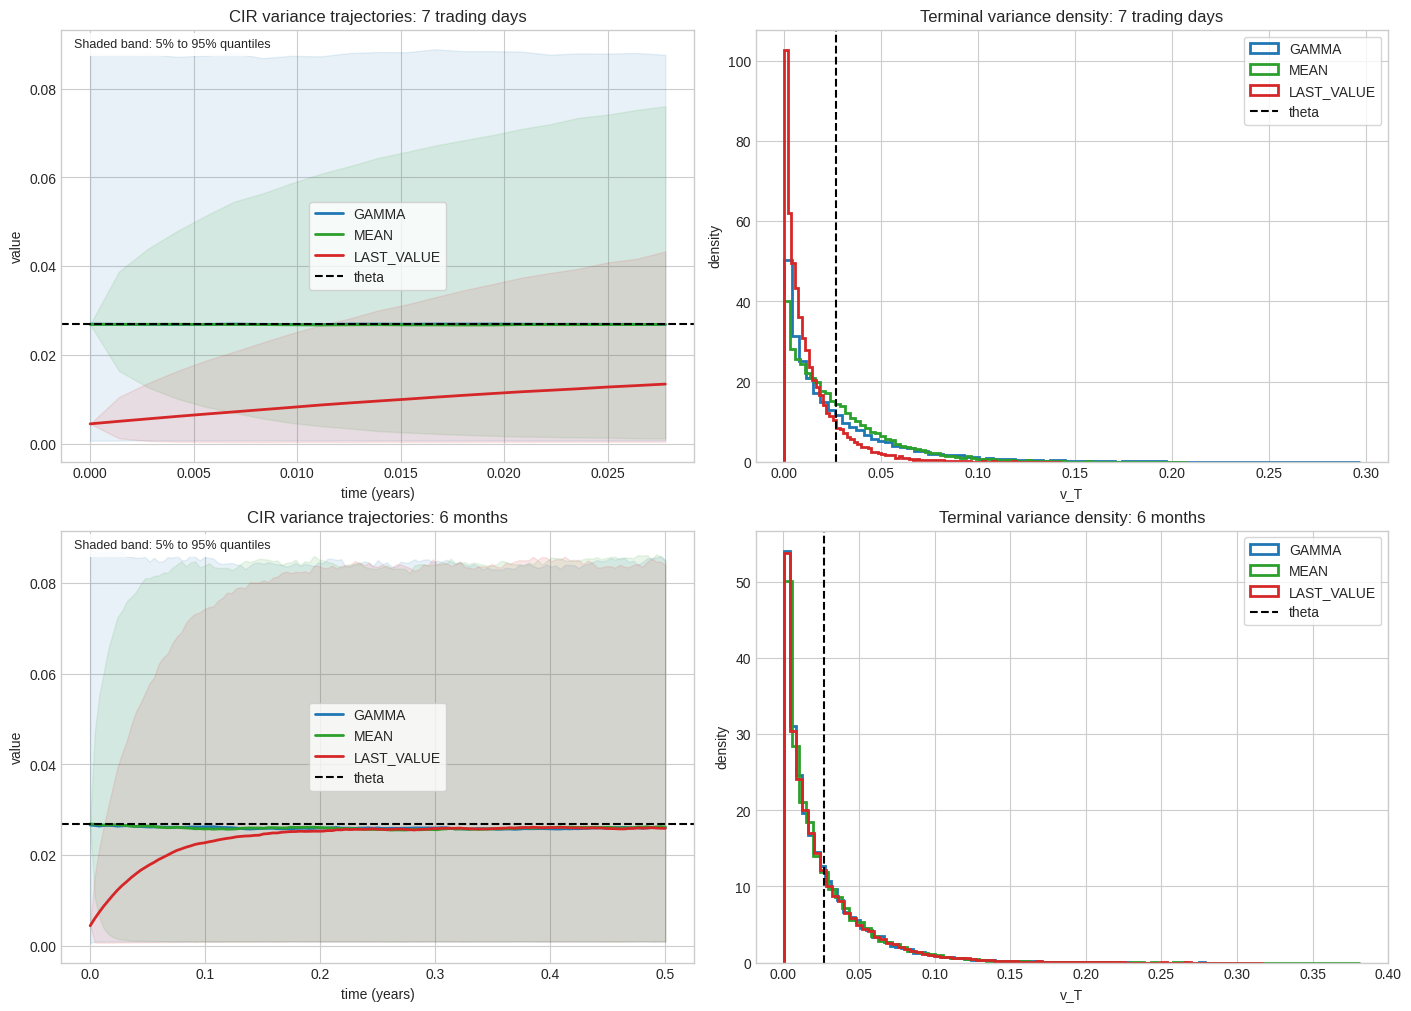

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

for row, (label, maturity, bundle) in enumerate(
    [
        ("7 trading days", short_maturity, cir_short),
        ("6 months", half_year, cir_half),
    ]
):
    ax_path, ax_hist = axes[row]

    for strategy in strategy_order:
        times = bundle[strategy]["times"]
        variance = bundle[strategy]["variance"]
        mean_path = variance.mean(axis=0)
        q05, q95 = np.quantile(variance, [0.05, 0.95], axis=0)

        ax_path.plot(times, mean_path, color=strategy_colors[strategy], linewidth=2, label=strategy_labels[strategy])
        ax_path.fill_between(times, q05, q95, color=strategy_colors[strategy], alpha=0.10)

        ax_hist.hist(variance[:, -1], bins=80, density=True, histtype="step", linewidth=2, color=strategy_colors[strategy], label=strategy_labels[strategy])

    ax_path.axhline(theta, color="black", linestyle="--", linewidth=1.5, label="theta")
    ax_path.set_title(f"CIR variance trajectories: {label}")
    ax_path.text(
        0.02,
        0.98,
        "Shaded band: 5% to 95% quantiles",
        transform=ax_path.transAxes,
        va="top",
        fontsize=9,
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
    )
    ax_path.set_xlabel("time (years)")
    ax_path.set_ylabel("value")
    ax_path.legend(frameon=True)

    ax_hist.axvline(theta, color="black", linestyle="--", linewidth=1.5, label="theta")
    ax_hist.set_title(f"Terminal variance density: {label}")
    ax_hist.set_xlabel("v_T")
    ax_hist.set_ylabel("density")
    ax_hist.legend(frameon=True)

plt.show()


### CIR takeaways

- `GAMMA` is the only strategy that is stationary from the start. Its mean is already close to `theta`, and more importantly its whole distribution is already close to the long-run one at both horizons.
- `MEAN` starts with the correct unconditional mean but with zero initial dispersion. Over a short horizon, it understates the left tail near zero and compresses the entire distribution relative to the stationary law.
- `LAST_VALUE` conditions on the current variance regime. Here `0.0045 < theta`, so its short-term distribution starts below the long-run variance level and then mean-reverts upward, exactly as predicted by the formula `E[v_t | v_0] = theta + (v_0 - theta)e^{-kappa t}`.
- By 6 months the three curves are much closer. With `kappa = 19.28`, the memory of the initial condition decays very fast, so the practical difference between the strategies is mostly a short-maturity phenomenon.
- The small downward bias in the empirical mean and variance is most likely a discretisation effect of the boosted Milstein CIR scheme, which does not preserve the stationary Gamma law exactly.


## 2. Heston simulation under the same three initialisations

We now propagate the same variance choices through the Heston asset dynamics.
The repository uses:

- the boosted Milstein scheme for variance,
- an Euler step on the log-spot,
- a very strong negative spot/variance correlation `rho = -0.99`.

That last point is central: high variance states are associated with negative spot moves. In this section we therefore focus on the terminal spot distribution and on the summary statistics that reveal how the initial variance law changes short-maturity tails and skewness.


In [ ]:
heston_short = simulate_heston_bundle(parameters=parameter_table, maturity=short_maturity, n_steps=int(short_maturity * 252), n_paths=n_paths)
heston_half = simulate_heston_bundle(parameters=parameter_table, maturity=half_year, n_steps=int(half_year * 252), n_paths=n_paths)

heston_summary_short = summarise_heston_bundle(heston_short)
heston_summary_half = summarise_heston_bundle(heston_half)

print("terminal Heston 7d")
display(heston_summary_short.loc[heston_summary_short.index.get_level_values("time") == 7.0])

print("terminal Heston 6m")
display(heston_summary_half.loc[heston_summary_half.index.get_level_values("time") == 126.0])


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax_spot, (label, maturity, bundle) in zip(
    axes,
    [
        ("7 trading days", short_maturity, heston_short),
        ("6 months", half_year, heston_half),
    ],
):
    forward_mean = s0 * np.exp((r - q) * maturity)

    for strategy in strategy_order:
        terminal_spot = bundle[strategy]["spot"][:, -1]
        ax_spot.hist(
            terminal_spot,
            bins=100,
            density=True,
            histtype="step",
            linewidth=2,
            color=strategy_colors[strategy],
            label=strategy_labels[strategy],
        )

    ax_spot.axvline(forward_mean, color="black", linestyle="--", linewidth=1.5, label="risk-neutral mean")
    ax_spot.set_title(f"Terminal spot density: {label}")
    ax_spot.set_xlabel("S_T")
    ax_spot.set_ylabel("density")
    ax_spot.legend(frameon=True)

plt.show()


### Heston takeaways

- The three strategies keep almost the same risk-neutral mean for the spot, which is expected: the initialisation mainly changes higher moments and tail probabilities, not the drift.
- Over 7 trading days, the terminal spot density still reacts to the initial variance law. `GAMMA` injects a full stationary distribution at time zero, so it mixes low-volatility and high-volatility paths immediately. `MEAN` starts every path from `theta`, while `LAST_VALUE` starts here from `0.0045`, well below `theta = 0.02691`, and therefore begins from the calmest variance regime.
- The time-indexed Heston summary keeps the variance-channel diagnostics that were in the working version of the notebook. In the displayed terminal slices, differences in `Std(log-return)`, `Skew(log-return)`, tail probabilities, and `E[v_t]` show how the variance initialisation is transmitted to the spot distribution without repeating the CIR density plots.
- By 6 months, the terminal spot densities become much closer. This mirrors the CIR block: with `kappa = 19.28`, the memory of the initial variance law decays quickly, so the difference between the strategies is mainly a short-maturity phenomenon.

For the rest of the project, this matters because smile and exotic-option sensitivity are driven mostly by the short end. The stationary initial law is therefore most useful precisely where the standard deterministic start is least flexible.


## 3. Pricing comparison aligned with the article

The article's Table 4 reports European option prices in the stationary Heston model for maturity `T = 0.5`, strikes from `80` to `120`, and time grids `n = 30, 60, 90, 180`, with quantization grid sizes `(N1, N2) = (50, 10)`.

Our implementation is a Monte Carlo pricer, not the product quantization method used in the paper. The closest comparison we can make here is therefore:

- use the same calibrated Heston parameters,
- use the same maturity `T = 0.5`,
- use the same European call/put strikes shown in Table 4,
- use `n = 180`, the finest time grid displayed in the table,
- compare the three variance initialisations `GAMMA`, `MEAN`, and `LAST_VALUE` against the article references.

For the exotic products immediately discussed after Table 4, we also reuse the paper's data as much as possible: monthly exercisable Bermudan options with `K = 100`, `T = 0.5`, and an up-and-out barrier call with `K = 100`, `L = 115`, `T = 0.5`.


In [ ]:
article_maturity = 0.5
article_n_steps = 180
article_n_paths = 30_000
article_strategies = strategy_order

# Benchmarks and n = 180 quantization prices copied from Table 4 of the article.
table4_rows = [
    {"option_type": OptionType.CALL, "strike": 80.0, "benchmark": 20.17, "quantization_n180": 19.99},
    {"option_type": OptionType.CALL, "strike": 85.0, "benchmark": 15.56, "quantization_n180": 15.35},
    {"option_type": OptionType.CALL, "strike": 90.0, "benchmark": 11.24, "quantization_n180": 11.03},
    {"option_type": OptionType.CALL, "strike": 95.0, "benchmark": 7.383, "quantization_n180": 7.202},
    {"option_type": OptionType.CALL, "strike": 100.0, "benchmark": 4.196, "quantization_n180": 4.081},
    {"option_type": OptionType.PUT, "strike": 100.0, "benchmark": 4.469, "quantization_n180": 4.396},
    {"option_type": OptionType.PUT, "strike": 105.0, "benchmark": 7.171, "quantization_n180": 7.178},
    {"option_type": OptionType.PUT, "strike": 110.0, "benchmark": 10.86, "quantization_n180": 10.91},
    {"option_type": OptionType.PUT, "strike": 115.0, "benchmark": 15.38, "quantization_n180": 15.40},
    {"option_type": OptionType.PUT, "strike": 120.0, "benchmark": 20.30, "quantization_n180": 20.31},
]


def price_european_article_row(row: dict[str, float], strategy: InitialVarianceStrategy, seed: int) -> float:
    product = EuropeanOption(
        simulator=create_heston_simulator(seed=seed),
        strike=row["strike"],
        maturity=article_maturity,
        option_type=row["option_type"],
        n_paths=article_n_paths,
        n_steps=article_n_steps,
        strategy=strategy,
        last_variance=last_variance_for(strategy),
    )
    price, _ = product.price()
    return price


article_european_rows = []
for row_index, row in enumerate(table4_rows):
    output_row = {
        "type": row["option_type"].value,
        "strike": row["strike"],
        "article_benchmark": row["benchmark"],
        "article_quantization_n180": row["quantization_n180"],
    }
    for strategy_index, strategy in enumerate(article_strategies):
        output_row[strategy_labels[strategy]] = price_european_article_row(
            row=row,
            strategy=strategy,
            seed=20_000 + 10 * row_index + strategy_index,
        )
    article_european_rows.append(output_row)

article_european_comparison = pd.DataFrame(article_european_rows).set_index(["type", "strike"])

print("European options - Table 4 data, Monte Carlo with n = 180")
display(article_european_comparison.round(6))


In [ ]:
method_columns = [
    "article_benchmark",
    "article_quantization_n180",
    "GAMMA",
    "MEAN",
    "LAST_VALUE",
]
method_labels = {
    "article_benchmark": "Benchmark Table 4",
    "article_quantization_n180": "Quantization n=180",
    "GAMMA": "MC GAMMA",
    "MEAN": "MC MEAN",
    "LAST_VALUE": "MC LAST_VALUE",
}
method_colors = {
    "article_benchmark": "#4d4d4d",
    "article_quantization_n180": "#9467bd",
    "GAMMA": strategy_colors[InitialVarianceStrategy.GAMMA],
    "MEAN": strategy_colors[InitialVarianceStrategy.MEAN],
    "LAST_VALUE": strategy_colors[InitialVarianceStrategy.LAST_VALUE],
}
method_markers = {
    "article_benchmark": "X",
    "article_quantization_n180": "o",
    "GAMMA": "s",
    "MEAN": "^",
    "LAST_VALUE": "D",
}
option_rows = [
    ("call", "Call"),
    ("put", "Put"),
]
max_strikes = max(len(article_european_comparison.loc[option_type]) for option_type, _ in option_rows)

fig, axes = plt.subplots(len(option_rows), max_strikes, figsize=(15, 8), sharey=False, constrained_layout=True)
x_position = 0.0

for row_index, (option_type, option_label) in enumerate(option_rows):
    option_comparison = article_european_comparison.loc[option_type]
    strikes = option_comparison.index.to_numpy(dtype=float)

    for column_index in range(max_strikes):
        ax = axes[row_index, column_index]
        if column_index >= len(strikes):
            ax.axis("off")
            continue

        strike = strikes[column_index]
        values = option_comparison.loc[strike, method_columns]

        ax.axvline(x_position, color="#d0d0d0", linewidth=1.5, zorder=1)
        for column in method_columns:
            ax.scatter(
                x_position,
                values[column],
                s=80,
                marker=method_markers[column],
                color=method_colors[column],
                edgecolor="white",
                linewidth=0.8,
                label=method_labels[column],
                zorder=4,
            )

        ax.set_title(f"{option_label} K = {strike:.0f}", fontsize=10)
        ax.set_ylabel("price")
        ax.set_xlim(-0.5, 0.5)
        ax.set_xticks([x_position])
        ax.set_xticklabels([f"K={strike:.0f}"])
        ax.grid(axis="y", alpha=0.35)

        value_min = float(values.min())
        value_max = float(values.max())
        margin = max(0.05, 0.18 * (value_max - value_min))
        ax.set_ylim(value_min - margin, value_max + margin)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.995, 0.995), frameon=True)
fig.suptitle("European options: method prices by strike", fontsize=13)
plt.show()


### Article-style Bermudan and barrier inputs

The article then studies Bermudan options with monthly exercise dates and `K = 100`, followed by an up-and-out barrier call with `K = 100` and `L = 115`. The figures do not provide the same explicit benchmark table as Table 4, so the values labelled `Article N1=...` below are approximate readings from Figures 11 and 12 at `n = 180`. They are useful for a visual comparison, but should not be read as exact table values.


In [ ]:
article_strike = 100.0
article_barrier = 115.0
article_exercise_times = np.arange(1, 7) / 12

# Approximate values read from Figures 11 and 12 at n = 180.
article_exotic_references = {
    "Bermudan call": {
        "article_N1_60": 4.09,
        "article_N1_90": 4.15,
        "article_N1_180": 4.21,
    },
    "Bermudan put": {
        "article_N1_60": 4.35,
        "article_N1_90": 4.40,
        "article_N1_180": 4.49,
    },
    "Up-and-out call": {
        "article_N1_50": 2.845,
        "article_N1_100": 2.81,
        "article_N1_200": 2.78,
    },
}

article_exotic_rows = []
for product_index, (product_name, option_type) in enumerate(
    [
        ("Bermudan call", OptionType.CALL),
        ("Bermudan put", OptionType.PUT),
    ]
):
    output_row = {"product": product_name, **article_exotic_references[product_name]}
    for strategy_index, strategy in enumerate(article_strategies):
        product = BermudanOption(
            simulator=create_heston_simulator(seed=30_000 + 10 * product_index + strategy_index),
            strike=article_strike,
            maturity=article_maturity,
            exercise_times=article_exercise_times,
            option_type=option_type,
            polynomial_degree=2,
            n_paths=article_n_paths,
            n_steps=article_n_steps,
            strategy=strategy,
            last_variance=last_variance_for(strategy),
        )
        price, _ = product.price()
        output_row[strategy_labels[strategy]] = price
    article_exotic_rows.append(output_row)

barrier_row = {"product": "Up-and-out call", **article_exotic_references["Up-and-out call"]}
for strategy_index, strategy in enumerate(article_strategies):
    barrier_product = BarrierOption(
        simulator=create_heston_simulator(seed=30_100 + strategy_index),
        strike=article_strike,
        maturity=article_maturity,
        barrier=article_barrier,
        direction=BarrierDirection.UP_AND_OUT,
        option_type=OptionType.CALL,
        use_brownian_bridge=True,
        n_paths=article_n_paths,
        n_steps=article_n_steps,
        strategy=strategy,
        last_variance=last_variance_for(strategy),
    )
    price, _ = barrier_product.price()
    barrier_row[strategy_labels[strategy]] = price
article_exotic_rows.append(barrier_row)

article_exotic_comparison = pd.DataFrame(article_exotic_rows).set_index("product")

print("Bermudan and barrier options - article-style inputs")
display(article_exotic_comparison.round(6))


In [ ]:
article_exotic_columns = [
    column
    for column in article_exotic_comparison.columns
    if column.startswith("article_")
]
mc_exotic_columns = ["GAMMA", "MEAN", "LAST_VALUE"]

exotic_method_labels = {
    "GAMMA": "MC GAMMA",
    "MEAN": "MC MEAN",
    "LAST_VALUE": "MC LAST_VALUE",
}
exotic_method_colors = {
    "GAMMA": strategy_colors[InitialVarianceStrategy.GAMMA],
    "MEAN": strategy_colors[InitialVarianceStrategy.MEAN],
    "LAST_VALUE": strategy_colors[InitialVarianceStrategy.LAST_VALUE],
}
exotic_method_markers = {
    "GAMMA": "s",
    "MEAN": "^",
    "LAST_VALUE": "D",
}
article_palette = ["#17becf", "#ff7f0e", "#2ca02c", "#9467bd", "#8c564b", "#e377c2"]
article_markers = ["o", "v", "*", "P", "X", "h"]

for index, column in enumerate(article_exotic_columns):
    suffix = column.replace("article_", "").replace("_", "=")
    exotic_method_labels[column] = f"Article {suffix}"
    exotic_method_colors[column] = article_palette[index % len(article_palette)]
    exotic_method_markers[column] = article_markers[index % len(article_markers)]


def plot_exotic_products(product_names: list[str], title: str, figsize: tuple[int, int]) -> None:
    fig, axes = plt.subplots(1, len(product_names), figsize=figsize, sharey=False, constrained_layout=True)
    axes = np.atleast_1d(axes)
    x_position = 0.0

    for ax, product_name in zip(axes, product_names):
        row = article_exotic_comparison.loc[product_name]
        product_method_columns = [
            column
            for column in [*article_exotic_columns, *mc_exotic_columns]
            if column in row.index and pd.notna(row[column])
        ]
        values = row[product_method_columns]

        ax.axvline(x_position, color="#d0d0d0", linewidth=1.5, zorder=1)
        for column in product_method_columns:
            ax.scatter(
                x_position,
                values[column],
                s=85,
                marker=exotic_method_markers[column],
                color=exotic_method_colors[column],
                edgecolor="white",
                linewidth=0.8,
                label=exotic_method_labels[column],
                zorder=4,
            )

        ax.set_title(product_name, fontsize=10)
        ax.set_ylabel("price")
        ax.set_xlim(-0.5, 0.5)
        ax.set_xticks([x_position])
        ax.set_xticklabels([product_name], rotation=15, ha="right")
        ax.grid(axis="y", alpha=0.35)

        value_min = float(values.min())
        value_max = float(values.max())
        margin = max(0.05, 0.18 * (value_max - value_min))
        ax.set_ylim(value_min - margin, value_max + margin)

    handles_by_label = {}
    for ax in axes:
        handles, labels = ax.get_legend_handles_labels()
        handles_by_label.update(dict(zip(labels, handles)))
    fig.legend(
        handles_by_label.values(),
        handles_by_label.keys(),
        loc="upper right",
        bbox_to_anchor=(0.995, 0.995),
        frameon=True,
    )
    fig.suptitle(title, fontsize=13)
    plt.show()


plot_exotic_products(
    product_names=["Bermudan call", "Bermudan put"],
    title="Bermudan options: article readings and MC strategies",
    figsize=(9, 4),
)


In [ ]:
plot_exotic_products(
    product_names=["Up-and-out call"],
    title="Barrier option: article readings and MC strategies",
    figsize=(5, 4),
)


### Pricing analysis

- For the European options, the Monte Carlo prices are broadly consistent with Table 4. The `GAMMA` column is usually very close to the article benchmark: for example the at-the-money call is around `4.18` versus a benchmark of `4.196`, and the at-the-money put is around `4.39` versus `4.469`. The article's own quantization price with `n = 180` is also slightly below the benchmark for the at-the-money call and put, so the Monte Carlo gap is of the same qualitative order.
- Across European strikes, `GAMMA` and `MEAN` are close to one another, while `LAST_VALUE` is generally lower near the money. This is expected because `last_variance = 0.0045` starts the variance process far below `theta = 0.02691`, reducing short-term optionality. The effect is most visible around `K = 95, 100, 105`, where convexity and volatility sensitivity matter most.
- The Bermudan call is very close to the article readings at `n = 180`: the article is around `4.21`, while `GAMMA` and `MEAN` are around `4.19`. `LAST_VALUE` is lower, again because the low initial variance reduces the value of optionality. For the Bermudan put, `MEAN` is the closest to the article reading around `4.49`, while `GAMMA` and especially `LAST_VALUE` are lower.
- The barrier option is the clear outlier. The article readings at `n = 180` are around `2.78` to `2.85`, while the Monte Carlo prices are materially higher, roughly `3.20` for `GAMMA`, `3.24` for `MEAN`, and `3.39` for `LAST_VALUE` after the Heston-adapted bridge correction. This suggests that the difference is not just sampling noise or the initial variance strategy: the barrier convention and numerical method are likely driving the gap.
- The most plausible explanation for the barrier discrepancy is methodological. The article uses product recursive quantization, while the notebook uses path Monte Carlo with a Brownian-bridge survival correction adapted to the Heston correlation. Barrier products are very sensitive to how crossing is detected between time steps and to how the spot/variance dynamics are discretized. With `rho = -0.99`, conditioning on the variance path leaves only a small independent Brownian component in the bridge, which increases survival probabilities and therefore pushes the Monte Carlo barrier prices further above the article values.
